In [1]:
import bz2
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy import stats

In [2]:
def open_data(file_path):
    """
    Open a bz2 compressed pickle file and return the uncompressed data.
    """
    data = []
    with bz2.BZ2File(file_path, 'rb') as f:
        while True:
            try:
                item = pickle.load(f)
                data.append(item)
            except EOFError:
                break
    return data

In [3]:
def clear_data(data):
    """
    Clear the data to only keep the relevant information.
    """
    reward_means = []
    q_values_means =    []
    for run in data:  
        run_rewards = []
        run_q_values = []
        for item in run:
            if item[0] == 'reward/max':
                run_rewards.append((item[1], item[2]))  # (step, value)
            if item[0] == 'q_values/max':
                run_q_values.append((item[1], item[2]))
        reward_means.append(run_rewards)
        q_values_means.append(run_q_values)

    reward_means = list(set(item for sublist in reward_means for item in sublist))
    q_values_means = list(set(item for sublist in q_values_means for item in sublist))
    reward_means.sort(key=lambda x: x[0])
    q_values_means.sort(key=lambda x: x[0])
    return reward_means, q_values_means

In [ ]:
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

def plot_with_variability(data, labels, colors, stat='mean', variability='std', smooth_window=15,
                          title='Performance over iterations',xlabel="Itération",ylabel="Value",show_runs=True):       #code qui se répéte pour faire des graphs mutliples ou simple
    """                                                                                                                                   #le mieux serait de regrouper les deux
    runs: list of list of tuples (iteration, value)
    stat: 'mean' or 'median'
    variability: 'std', 'sem', 'var', 'iqr', 'ci'
    smooth_window: window size for moving average smoothing
    show_runs: whether to plot individual smoothed runs
    """

    # Regrouper les valeurs par itération
    i=0
    for runs in data:
        data_by_iter = defaultdict(list)
        for run in runs:
            for it, val in run:
                data_by_iter[it].append(val)

        iterations = sorted(data_by_iter.keys())
        stat_values = []
        var_values = []

        for it in iterations:
            values = np.array(data_by_iter[it])

            # Moyenne ou médiane
            if stat == 'mean':
                stat_val = np.mean(values)
            elif stat == 'median':
                stat_val = np.median(values)
            else:
                raise ValueError("Unknown stat. Use 'mean' or 'median'.")
            stat_values.append(stat_val)

            # Variabilité
            if variability == 'std':
                var_val = np.std(values)
            elif variability == 'sem':
                var_val = np.std(values) / np.sqrt(len(values))
            elif variability == 'var':
                var_val = np.var(values)
            elif variability == 'iqr':
                q75, q25 = np.percentile(values, [75, 25])
                var_val = (q75 - q25) / 2
            elif variability == 'ci':
                sem = np.std(values) / np.sqrt(len(values))
                var_val = 1.96 * sem
            else:
                raise ValueError("Unknown variability type.")
            var_values.append(var_val)

        # Convertir en numpy arrays
        stat_values = np.array(stat_values)
        var_values = np.array(var_values)

        # Appliquer le lissage
        smoothed_stat = moving_average(stat_values, smooth_window)
        smoothed_var = moving_average(var_values, smooth_window)
        smoothed_iters = iterations[(smooth_window - 1):]

        # Plot
        
        #plt.figure(figsize=(10, 6))

        if show_runs:
            for run in runs:
                run = sorted(run, key=lambda x: x[0])  # assure tri par itérations
                iters, vals = zip(*run)
                if len(vals) >= smooth_window:
                    smoothed_vals = moving_average(np.array(vals), smooth_window)
                    smoothed_it = iters[(smooth_window - 1):]
                    plt.plot(smoothed_it, smoothed_vals, color=colors[i], alpha=0.3, linewidth=1)

        # Courbe moyenne/mediane + bande
        plt.plot(smoothed_iters, smoothed_stat, color= colors[i],label=f'{labels[i]}')
        plt.fill_between(smoothed_iters,
                        smoothed_stat - 3*smoothed_var,
                        smoothed_stat + 3*smoothed_var,
                        color='blue', alpha=0.3, label=f'{variability.upper()} (smoothed)')
        i+=1

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
        
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [83]:
# Liste des chemins pour chaque type de fichier
files_path = {
    "van": ["data/ll_data/vanille/seed0/db.pickle.bzip2", "data/ll_data/vanille/seed1/db.pickle.bzip2"],
    "van_act": ["data/ll_data/vanille_act/seed0/db.pickle.bzip2", "data/ll_data/vanille_act/seed1/db.pickle.bzip2"],
    "theta_ext": ["data/ll_data/theta_ext/seed0/db.pickle.bzip2", "data/ll_data/theta_ext/seed1/db.pickle.bzip2"],
    "theta_ext_act": ["data/ll_data/theta_ext_act/seed0/db.pickle.bzip2", "data/ll_data/theta_ext_act/seed1/db.pickle.bzip2"],
    "xy_ext": ["data/ll_data/xy_ext/seed0/db.pickle.bzip2", "data/ll_data/xy_ext/seed1/db.pickle.bzip2"],
    "xy_ext_act": ["data/ll_data/xy_ext_act/seed0/db.pickle.bzip2", "data/ll_data/xy_ext_act/seed1/db.pickle.bzip2"],
    "theta_xy_ext": ["data/ll_data/theta_xy_ext/seed0/db.pickle.bzip2", "data/ll_data/theta_xy_ext/seed1/db.pickle.bzip2"],
    "theta_xy_ext_act": ["data/ll_data/theta_xy_ext_act/seed0/db.pickle.bzip2", "data/ll_data/theta_xy_ext_act/seed1/db.pickle.bzip2"],
    "theta_xy_ext_act3": ["data/ll_data/theta_xy_ext_act3/seed0/db.pickle.bzip2", "data/ll_data/theta_xy_ext_act3/seed1/db.pickle.bzip2"],
    "theta_xy_ext_act4": ["data/ll_data/theta_xy_ext_act4/seed0/db.pickle.bzip2", "data/ll_data/theta_xy_ext_act4/seed1/db.pickle.bzip2"]
}

colors = ['r', 'g', 'b', 'y', 'c', 'm', 'k', 'pink', 'orange', 'purple']

# Dictionnaire pour stocker les rewards et q_values
reward_dict = {
    "reward_van": [],                               #r
    "reward_van_act": [],                           #g
    "reward_theta_ext": [],                         #b
    "reward_theta_ext_act": [],                     #y
    "reward_xy_ext": [],                            #c
    "reward_xy_ext_act": [],                        #m
    "reward_theta_xy_ext": [],                      #k
    "reward_theta_xy_ext_act": [],                  #pink
    "reward_theta_xy_ext_act3": [],                 #orange
    "reward_theta_xy_ext_act4": []                  #purple
}

q_values_dict = {
    "q_values_van": [],                             #r
    "q_values_van_act": [],                         #g 
    "q_values_theta_ext": [],                       #b
    "q_values_theta_ext_act": [],                   #y
    "q_values_xy_ext": [],                          #c
    "q_values_xy_ext_act": [],                      #m
    "q_values_theta_xy_ext": [],                    #k
    "q_values_theta_xy_ext_act": [],                #pink
    "q_values_theta_xy_ext_act3": [],               #orange
    "q_values_theta_xy_ext_act4": []                #purple
}

# Fonction pour charger et nettoyer les données
def load_and_clear_data(file_paths):
    data = [open_data(file_path) for file_path in file_paths]
    return [clear_data(d) for d in data]

# Parcours de chaque type de fichier et ajout des données dans les bonnes listes
for category in files_path:
    # Charger et nettoyer les données
    data = load_and_clear_data(files_path[category])
    
    # Ajouter les reward et q_values dans leurs listes respectives
    for i, (reward, q_values) in enumerate(data):
        reward_dict[f"reward_{category}"].append(reward)
        q_values_dict[f"q_values_{category}"].append(q_values)

# À ce point, reward_dict et q_values_dict contiennent toutes les données organisées par catégorie


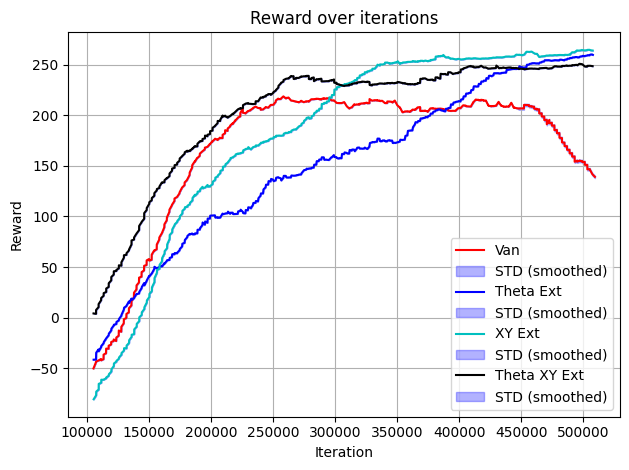

In [95]:
graph_wraps_bas_r = [reward_dict["reward_van"], reward_dict["reward_theta_ext"], reward_dict["reward_xy_ext"], reward_dict["reward_theta_xy_ext"]]
labels1  = ["Van", "Theta Ext", "XY Ext", "Theta XY Ext"]
colors1 = ['r', 'b', 'c', 'k']

plot_with_variability(graph_wraps_bas_r, labels1, colors1, stat='mean', variability='std', smooth_window=100, title='Reward over iterations', xlabel="Iteration", ylabel="Reward", show_runs=False)

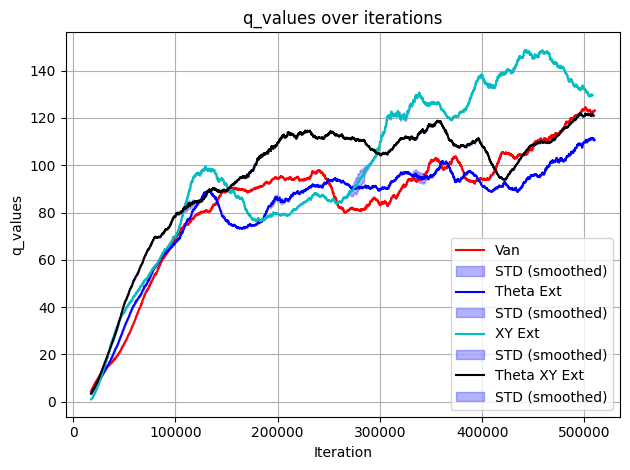

In [96]:
graph_wraps_bas_q = [q_values_dict["q_values_van"], q_values_dict["q_values_theta_ext"], q_values_dict["q_values_xy_ext"], q_values_dict["q_values_theta_xy_ext"]]
labels2= ["Van", "Theta Ext", "XY Ext", "Theta XY Ext"]
colors2 = ['r', 'b', 'c', 'k']

plot_with_variability(graph_wraps_bas_q, labels2, colors2, stat='mean', variability='std', smooth_window=100, title='q_values over iterations', xlabel="Iteration", ylabel="q_values", show_runs=False)

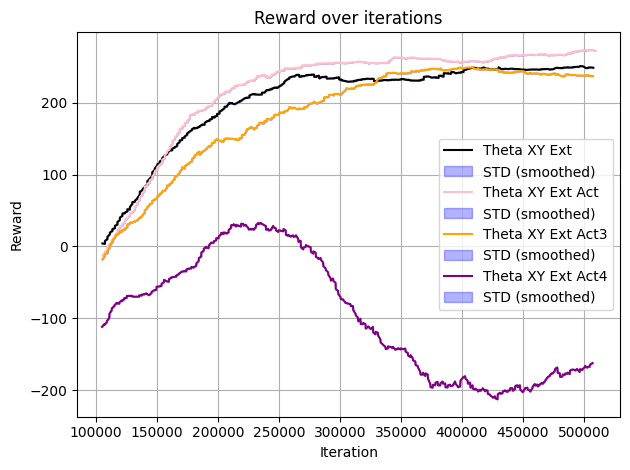

In [97]:
graph_action_wrap_r = [reward_dict["reward_theta_xy_ext"], reward_dict["reward_theta_xy_ext_act"], reward_dict["reward_theta_xy_ext_act3"], reward_dict["reward_theta_xy_ext_act4"]]
labels4 = ["Theta XY Ext", "Theta XY Ext Act", "Theta XY Ext Act3", "Theta XY Ext Act4"]
colors4 = ['k', 'pink', 'orange', 'purple']

plot_with_variability(graph_action_wrap_r, labels4, colors4, stat='mean', variability='std', smooth_window=100, title='Reward over iterations', xlabel="Iteration", ylabel="Reward", show_runs=False)

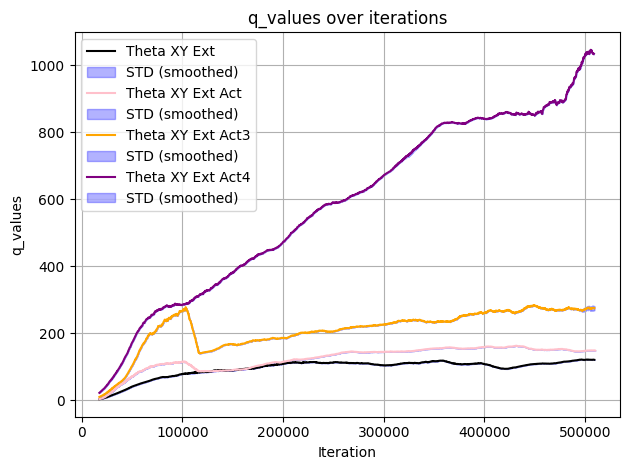

In [98]:
graph_action_wrap_q = [q_values_dict["q_values_theta_xy_ext"], q_values_dict["q_values_theta_xy_ext_act"], q_values_dict["q_values_theta_xy_ext_act3"], q_values_dict["q_values_theta_xy_ext_act4"]]
labels5 = ["Theta XY Ext", "Theta XY Ext Act", "Theta XY Ext Act3", "Theta XY Ext Act4"]
colors5 = ['k', 'pink', 'orange', 'purple']



plot_with_variability(graph_action_wrap_q, labels5, colors5, stat='mean', variability='std', smooth_window=100, title='q_values over iterations', xlabel="Iteration", ylabel="q_values", show_runs=False)

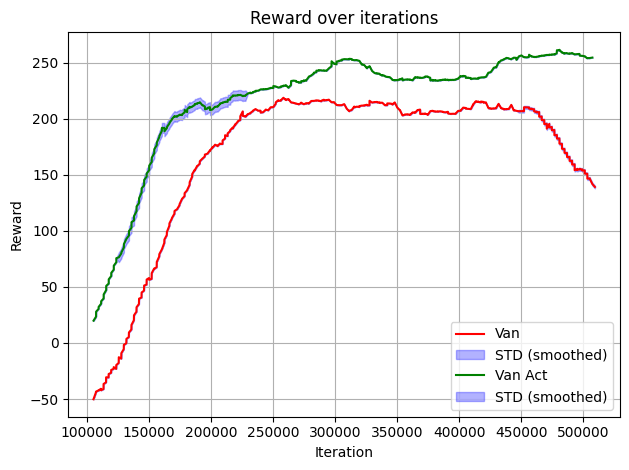

In [122]:
graph_van_act = [reward_dict["reward_van"], reward_dict["reward_van_act"]]
labels6 = ["Van", "Van Act"]
colors6 = ['r', 'g']

plot_with_variability(graph_van_act, labels6, colors6, stat='mean', variability='std', smooth_window=100, title='Reward over iterations', xlabel="Iteration", ylabel="Reward", show_runs=False)

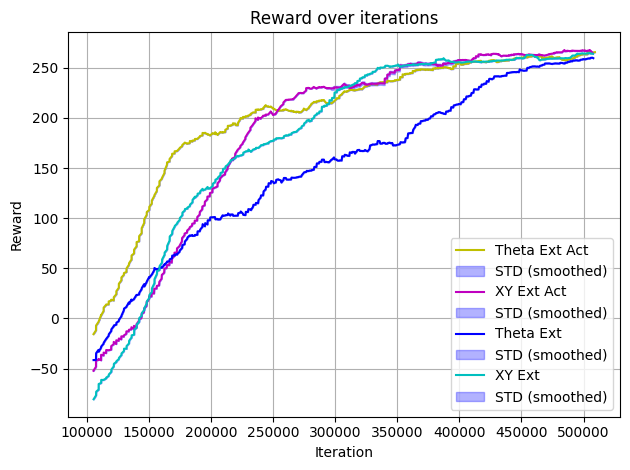

In [100]:
graph_theta_or_xy_r = [reward_dict["reward_theta_ext_act"], reward_dict["reward_xy_ext_act"], reward_dict["reward_theta_ext"], reward_dict["reward_xy_ext"]]
labels7 = ["Theta Ext Act", "XY Ext Act", "Theta Ext", "XY Ext"]
colors7 = ['y', 'm', 'b', 'c']

plot_with_variability(graph_theta_or_xy_r, labels7, colors7, stat='mean', variability='std', smooth_window=100, title='Reward over iterations', xlabel="Iteration", ylabel="Reward", show_runs=False)

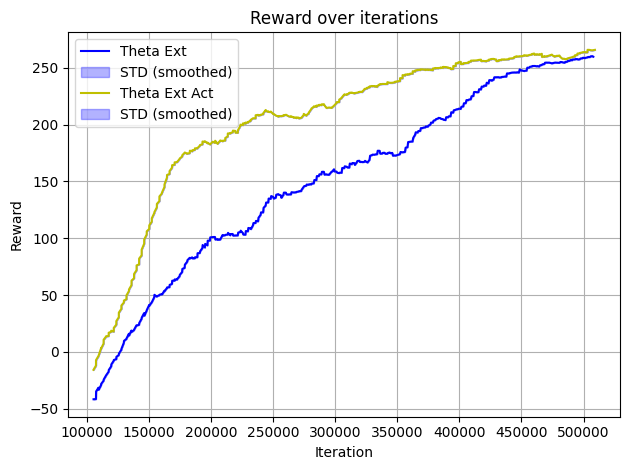

In [101]:
graph_theta = [reward_dict["reward_theta_ext"], reward_dict["reward_theta_ext_act"]]
labels = ["Theta Ext", "Theta Ext Act"]
colors = ['b', 'y']
plot_with_variability(graph_theta, labels, colors, stat='mean', variability='std', smooth_window=100, title='Reward over iterations', xlabel="Iteration", ylabel="Reward", show_runs=False)

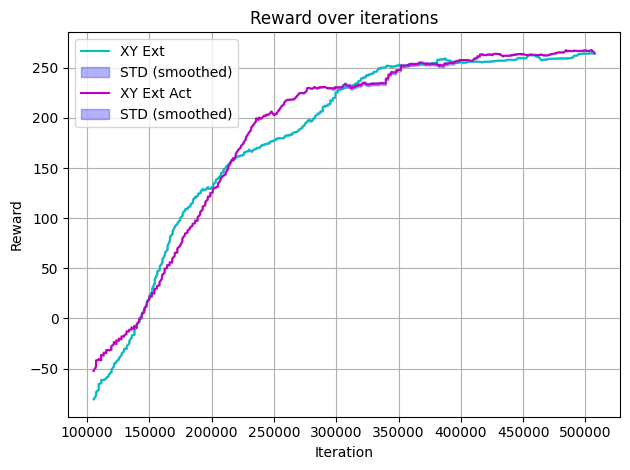

In [102]:
graph_xy = [reward_dict["reward_xy_ext"], reward_dict["reward_xy_ext_act"]]
labels = ["XY Ext", "XY Ext Act"]
colors = ['c', 'm']

plot_with_variability(graph_xy, labels, colors, stat='mean', variability='std', smooth_window=100, title='Reward over iterations', xlabel="Iteration", ylabel="Reward", show_runs=False)

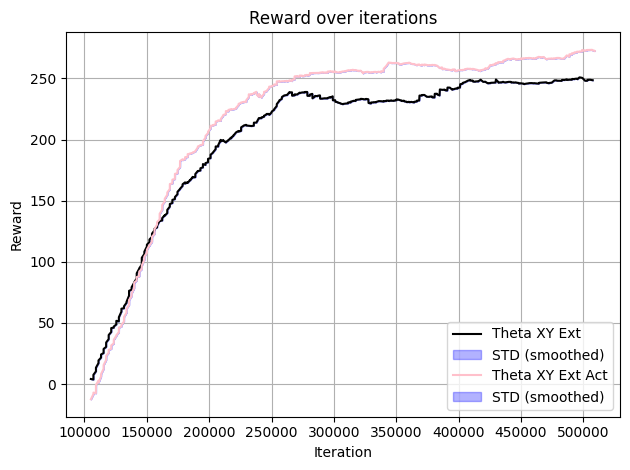

In [103]:
graph_theta_xy = [reward_dict["reward_theta_xy_ext"], reward_dict["reward_theta_xy_ext_act"]]
labels = ["Theta XY Ext", "Theta XY Ext Act"]
colors = ['k', 'pink']
plot_with_variability(graph_theta_xy, labels, colors, stat='mean', variability='std', smooth_window=100, title='Reward over iterations', xlabel="Iteration", ylabel="Reward", show_runs=False)

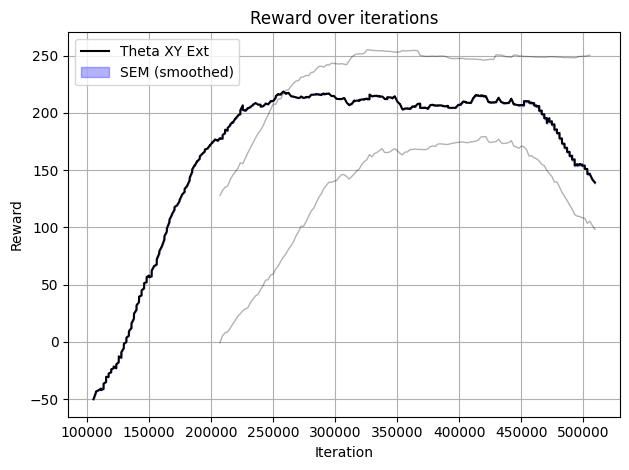

In [121]:
graph_theta_xy = [reward_dict["reward_van"]]
labels = ["Theta XY Ext"]
colors = ['k']
plot_with_variability(graph_theta_xy, labels, colors, stat='mean', variability='sem', smooth_window=100, title='Reward over iterations', xlabel="Iteration", ylabel="Reward", show_runs=True)